In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Cell 2: Load Dataset
# Ensure 'netflix_titles.csv' is in your working directory
df = pd.read_csv('netflix_titles.csv')
print("Dataset Shape:", df.shape)
display(df.head())

# Cell 3: Data Cleaning & Preprocessing
# Drop rows with missing crucial values
df = df.dropna(subset=['type', 'release_year', 'rating'])

# Create a binary target: 1 if it's a 'Movie', 0 if it's a 'TV Show'
df['is_movie'] = np.where(df['type'] == 'Movie', 1, 0)

# Fill missing country info with 'Unknown' and rating with 'Not Rated'
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

# Encode categorical columns
le = LabelEncoder()
df['rating_encoded'] = le.fit_transform(df['rating'])
df['country_encoded'] = le.fit_transform(df['country'])

# Select features and target variable
features = ['release_year', 'rating_encoded', 'country_encoded']
X = df[features]
y = df['is_movie']

# Cell 4: Exploratory Data Analysis & Visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='type', data=df, palette='Set2')
plt.title('Distribution of Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['release_year'], bins=30, kde=True, color='crimson')
plt.title('Distribution of Content Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.xlim(2000, 2026)
plt.show()

# Cell 5: Machine Learning Model Training & Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# Cell 6: Model Predictions & Metrics
y_pred = clf.predict(X_test_scaled)
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

<class 'ModuleNotFoundError'>: No module named 'seaborn'

Dataset Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


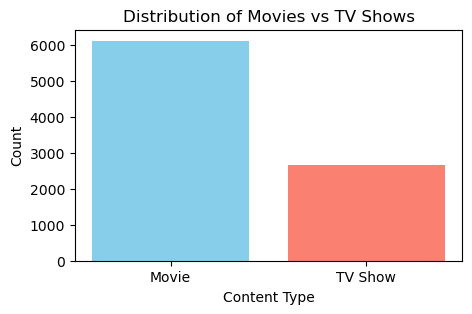

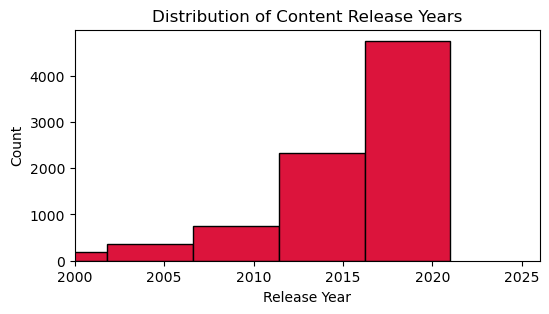

Accuracy Score: 0.7433276547416241

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.53      0.57       566
           1       0.79      0.85      0.82      1195

    accuracy                           0.74      1761
   macro avg       0.70      0.69      0.69      1761
weighted avg       0.74      0.74      0.74      1761



In [3]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Cell 2: Load Dataset
# Ensure 'netflix_titles.csv' is in your working directory
df = pd.read_csv('netflix_titles.csv')
print("Dataset Shape:", df.shape)
display(df.head())

# Cell 3: Data Cleaning & Preprocessing
df = df.dropna(subset=['type', 'release_year', 'rating'])
df['is_movie'] = np.where(df['type'] == 'Movie', 1, 0)

df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

le = LabelEncoder()
df['rating_encoded'] = le.fit_transform(df['rating'])
df['country_encoded'] = le.fit_transform(df['country'])

features = ['release_year', 'rating_encoded', 'country_encoded']
X = df[features]
y = df['is_movie']

# Cell 4: Data Visualization using pure Matplotlib
type_counts = df['type'].value_counts()
plt.figure(figsize=(5, 3))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'salmon'])
plt.title('Distribution of Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 3))
plt.hist(df['release_year'], bins=20, color='crimson', edgecolor='black')
plt.title('Distribution of Content Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.xlim(2000, 2026)
plt.show()

# Cell 5: Machine Learning Model Training & Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))